# 1. Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from IPython import display
from datetime import datetime

# 2. Set Variables

In [3]:
IMG_SIZE = 28          # Kích thước ảnh 28x28
INP_LENGTH = 784       # Số lượng pixel sau khi duỗi phẳng
NUM_CLASS = 10         # 10 chữ số (0-9)
NUM_TRAIN = 60000       # Giới hạn số mẫu train để code chạy nhanh (tăng lên 60000 nếu muốn)
NUM_TEST = 10000        # Số mẫu test

COLOR_LIST =['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#1f77b4']

# 3. Load X (image) & Y (label)

In [4]:
print("Đang tải dữ liệu MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"].astype(int)

# Chia Train / Test
train_x, test_x = X[:NUM_TRAIN], X[60000:60000+NUM_TEST]
train_y, test_y = y[:NUM_TRAIN], y[60000:60000+NUM_TEST]

# Chuẩn hóa dữ liệu về đoạn [-1, 1]
def scale_x(data_x):
    return (data_x / 255) * 2 - 1

train_x = scale_x(train_x)
test_x = scale_x(test_x)
print(f"Hoàn tất tải dữ liệu. Kích thước Train: {train_x.shape}, Kích thước Test: {test_x.shape}")

Đang tải dữ liệu MNIST...
Hoàn tất tải dữ liệu. Kích thước Train: (60000, 784), Kích thước Test: (10000, 784)


# 4. Activation Functions

Sigmoid:

\begin{equation}
S(x) = \frac{1}{1+e^{-x}}
\end{equation}

\begin{equation}
S(z)_i = \frac{1}{1+e^{-z_i}}
\end{equation}

Softmax:

\begin{equation}
\sigma(z)_i = \frac{e^{z_i}}{\sum^n_{j=1}e^{z_j}}
\end{equation}

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z):
    exp_arr = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_arr / np.sum(exp_arr, axis=1, keepdims=True)

# 5. Derivative of Activation Functions

Derivative of Sigmoid:

\begin{equation}
S'(x) = \frac{e^{-x}}{(1+e^{-x})^2} = S(x)(1-S(x))
\end{equation}

\begin{equation}
S'(a)_i = \frac{e^{-a_i}}{(1+e^{-a_i})^2} = S(a_i)(1-S(a_i))
\end{equation}

In [6]:
def sigmoid_derv(a):
    return np.multiply(a, 1 - a)

# 6. Processing Functions

One-hot encoder:

0 => [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]<br>
5 => [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]<br>
9 => [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [7]:
def make_one_hot(y):
    one_hot = np.zeros(NUM_CLASS)
    one_hot[y] = 1
    return one_hot

# 7. Build Model

Feed-forward:

\begin{align}
z^{(l)} & = \big(bias+a^{(l-1)}\big).W^{(l-1)} \\
a^{(l)} & = activation^{(l)}\big(z^{(l)}\big) \\\\
a^{(0)} & = x = \text{input} \\
z^{(1)} & = \big([1]+a^{(0)}\big).W^{(0)} \\
a^{(1)} & = S\big(z^{(1)}\big) = \text{hidden layer} \\
z^{(2)} & = \big([1]+a^{(1)}\big).W^{(1)} \\
a^{(2)} & = \sigma\big(z^{(2)}\big) = \hat{y} = \text{output}
\end{align}

Loss function: Cross-entropy

\begin{align}
J(W) & = -\sum_{k=0}^{9} y_k \log\hat{y}_k \tag{for one example} \\
J(W) & = -\frac{1}{n}\sum_{i=0}^{n-1}\sum_{k=0}^{9} y^{(i)}_k \log\hat{y}^{(i)}_k + (1 - y^{(i)}_k) \log(1 - \hat{y}^{(i)}_k)\tag{for the entire dataset}
\end{align}

Backpropagation:

\begin{align}
\delta^{(L)} &= \frac{\partial J}{\partial z^{(L)}} = \frac{\partial J}{\partial a^{(L)}}\frac{\partial a^{(L)}}{\partial z^{(L)}} = a^{(L)}-y \\
\delta^{(l)} &= \frac{\partial J}{\partial z^{(l)}} = \bigg(\frac{\partial J}{\partial z^{(l+1)}}W^{(l)T}\bigg)\frac{\partial a^{(l)}}{\partial z^{(l)}} = \bigg(\delta^{(l+1)}W^{(l)T}\bigg)\frac{\partial activation^{(l)}\big(z^{(l)}\big)}{\partial z^{(l)}} \\
\frac{\partial J}{\partial W^{(l)}} &= \big(bias+a^{(l)T}\big)\frac{\partial J}{\partial z^{(l+1)}} = \big(bias+a^{(l)T}\big)\delta^{(l+1)} 
\end{align}

\begin{align}
\delta^{(2)} & = a^{(2)}-y = \hat{y}-y = output-y \\
\frac{\partial J}{\partial W^{(1)}} & = \big([1]+a^{(1)T}\big)\delta^{(2)} \\
\delta^{(1)} & = \big(\delta^{(2)}W^{(1)T}\big)\frac{\partial S\big(z^{(1)}\big)}{\partial z^{(1)}} \\
\frac{\partial J}{\partial W^{(0)}} & = \big([1]+a^{(0)T}\big)\delta^{(1)}
\end{align}

Update weights:

\begin{equation}
W^{(i)} = W^{(i)} - \alpha\frac{\partial J}{\partial W^{(i)}}
\end{equation}

In [8]:
class HDClassifierNN:
    def __init__(self, hidden_layer_size, learning_rate):
        self.layer_list = [INP_LENGTH, hidden_layer_size, NUM_CLASS]
        self.learning_rate = learning_rate
        self.w_list =[]
        self.trained_epochs = 0
        self.loss_list = [[],[]] # Chứa train_loss và test_loss

        # Khởi tạo ma trận trọng số  ngẫu nhiên W (đã cộng thêm 1 chiều cho bias)
        # Giảm biên độ xuống [-0.5, 0.5] để  Sigmoid hội tụ tốt hơn
        for i in range(len(self.layer_list) - 1):
            w = np.random.rand(self.layer_list[i] + 1, self.layer_list[i+1]) - 0.5
            self.w_list.append(w)

    def feed_forward(self, x):
        # Lan truyền xuôi và lưu lại giá trị các lớp để  tính đạo hàm
        a = x
        output_list = [a]
        # Lớp ẩn
        a = np.append([[1]], a, axis=1)
        z = np.matmul(a, self.w_list[0])
        a = sigmoid(z)
        output_list.append(a)
        # Lớp đầu ra
        a = np.append([[1]], a, axis=1)
        z = np.matmul(a, self.w_list[1])
        a = softmax(z)
        output_list.append(a)
        return output_list

    def cal_loss(self, prediction, label):
        # Cross-entropy loss cộng thêm epsilon nhỏ để  tránh log(0)
        return -np.log(prediction[0][label] + 1e-9)

    def cal_loss_set(self, data_x, data_y):
        total_loss = 0
        for i in range(len(data_y)):
            prediction = self.predict(data_x[i].reshape(1, 784))
            total_loss += self.cal_loss(prediction, data_y[i])
        return total_loss / len(data_y)

    def backpropagate(self, output_list, label):
        # Lan truyền ngược để  tìm gradient
        # Lớp đầu ra (Output layer)
        delta2 = output_list[-1] - make_one_hot(label)
        derv2 = np.matmul(np.append([[1]], output_list[-2].T, axis=0), delta2)
        derv_list =[derv2]

        # Lớp ẩn (Hidden layer)
        activation_derv = sigmoid_derv(output_list[-2])
        delta1 = np.multiply(np.matmul(delta2, self.w_list[-1][1: , : ].T), activation_derv)
        derv1 = np.matmul(np.append([[1]], output_list[-3].T, axis=0), delta1)
        derv_list.insert(0, derv1)
        return derv_list

    def update_weights(self, derv_list):
        # Cập nhật trọng số (Hạ Gradient / Gradient Descent)
        for i in range(len(self.w_list)):
            self.w_list[i] = self.w_list[i] - self.learning_rate * derv_list[i]
    
    def predict(self, x):
        # Mạng lan truyền xuôi
        a = x
        # Lớp ẩn
        a = np.append([[1]], a, axis=1)   # Thêm bias
        z = np.matmul(a, self.w_list[0])
        a = sigmoid(z)
        # Lớp đầu ra
        a = np.append([[1]], a, axis=1)   # Thêm bias
        z = np.matmul(a, self.w_list[1])
        a = softmax(z)
        return a

    def predict_class(self, x):
        prediction = self.predict(x)[0]
        predicted_class = np.argmax(prediction)
        certainty = prediction[predicted_class]
        return predicted_class, certainty

    def plot_losses(self, start_time=None):
        fig = plt.figure(figsize=(10, 4))
        ax = plt.subplot(xlabel='x100 examples', ylabel='Loss', title='Đồ thị Mất mát (Loss)')
        ax.plot(self.loss_list[0], label='Train Loss | {0:.2f}'.format(self.loss_list[0][-1]))
        ax.plot(self.loss_list[1], label='Test Loss | {0:.2f}'.format(self.loss_list[1][-1]))
        if start_time is not None:
            ax.text(0, -0.2, 'Thời gian: {}'.format(datetime.now() - start_time), transform=ax.transAxes)
        ax.legend()

# 8. Train function

In [9]:
def train(model, num_epoch, data_x_train, data_y_train, data_x_test, data_y_test):
    start_time = datetime.now()

    for epoch in range(num_epoch):
        model.trained_epochs += 1

        # Stochastic Gradient Descent (Duyệt qua từng mẫu)
        for i in range(len(data_y_train)):
            output_list = model.feed_forward(data_x_train[i].reshape(1, 784))
            grad_list = model.backpropagate(output_list, data_y_train[i])
            model.update_weights(grad_list)

            # Lưu và vẽ loss mỗi 500 mẫu để tránh biểu đồ quá rối
            if i % 500 == 0:
                train_loss = model.cal_loss_set(data_x_train[:500], data_y_train[:500]) # Lấy mẫu ngẫu nhiên để tính nhanh
                test_loss = model.cal_loss_set(data_x_test[:500], data_y_test[:500])
                model.loss_list[0].append(train_loss)
                model.loss_list[1].append(test_loss)

                display.clear_output(wait=True)
                print(f"Epoch {epoch+1}/{num_epoch} | Đang train mẫu thứ {i}/{len(data_y_train)}")
                model.plot_losses(start_time=start_time)
                plt.show()

# 9. Training

Epoch 3/3 | Đang train mẫu thứ 59500/60000


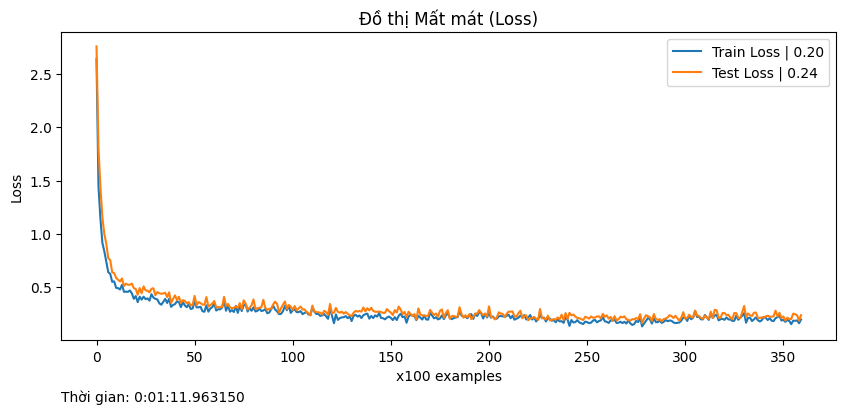

In [ ]:
hidden_layer_size = 50
learning_rate = 0.015
num_epochs = 5

# Khởi tạo mô hình
model = HDClassifierNN(hidden_layer_size, learning_rate)

# Bắt đầu quá trình học (Học trên 6000 mẫu, mất vài phút tùy tốc độ máy)
train(model, num_epochs, train_x, train_y, test_x, test_y)


# 10. Accuracy


Độ chính xác trên tập Train: 94.08%
Độ chính xác trên tập Test: 93.77%


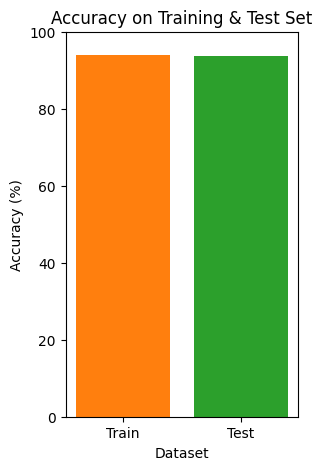

In [12]:
# Đánh giá độ chính xác
def cal_accuracy(model, data_x, data_y):
    correct_count = 0
    for i in range(len(data_y)):
        predicted_class, _ = model.predict_class(data_x[i].reshape(1, 784))
        if predicted_class == data_y[i]:
            correct_count += 1
    return (correct_count / len(data_y)) * 100

def plot_accuracy(acc_train, acc_test):
    # setup figure & axes
    fig = plt.figure(figsize=(3, 5))
    axe = plt.subplot(title='Accuracy on Training & Test Set', ylim=[0, 100], xlabel='Dataset', ylabel='Accuracy (%)')

    # plot accuracies for
    axe.bar(np.arange(2), [acc_train, acc_test], tick_label=['Train', 'Test'], color=COLOR_LIST)

    plt.show()

acc_train = cal_accuracy(model, train_x, train_y)
acc_test = cal_accuracy(model, test_x, test_y)
print(f"\nĐộ chính xác trên tập Train: {acc_train:.2f}%")
print(f"Độ chính xác trên tập Test: {acc_test:.2f}%")
plot_accuracy(acc_train, acc_test)

# 11. Run model on test set

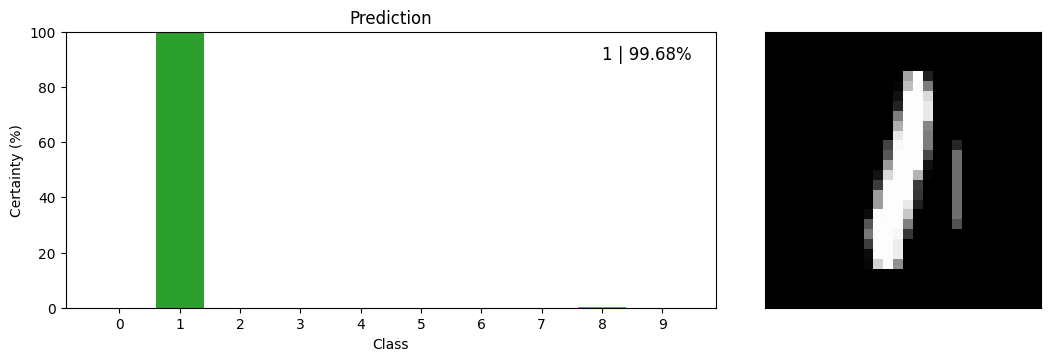

In [30]:
def show_prediction(model, x, show_class=None):

    # get prediction
    prediction = model.predict(x.reshape(1, 784))[0]
    predicted_class, certainty = model.predict_class(x.reshape(1, 784))

    # setup fig & axes
    gridspec_kw=dict(left=0, right=1, top=0.92, bottom=0, wspace=0.05, hspace=0.25, width_ratios=[2, 1])
    fig, axes = plt.subplots(nrows=1, ncols=2, gridspec_kw=gridspec_kw, figsize=(10, 3))

    # plot prediction vector
    axes[0].bar(np.arange(NUM_CLASS), prediction*100, tick_label=range(10), color=COLOR_LIST)
    axes[0].set_ylim(0, 100)
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Certainty (%)')
    axes[0].set_title('Prediction')
    axes[0].text(8, 90, '{} | '.format(predicted_class) + '{0:.2f}%'.format(certainty*100), fontsize=12)

    # plot image
    axes[1].imshow(np.reshape(x, (IMG_SIZE, IMG_SIZE)), cmap='gray')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.show()

random_idx = np.random.randint(len(test_y))
img = test_x[random_idx]
show_prediction(model, img)